In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from multiprocessing import Pool
from scipy.interpolate import RegularGridInterpolator
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# =========================
# Loading CC data
# =========================

# Path
cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"

# DataFrame
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

# Main columns
z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err   = df_cc["H_cc_err"].to_numpy(float)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Hard bounds
H0_min,    H0_max    = 50.0,  90.0
Om0_min,   Om0_max   = 0.1,   0.6
mu_HS_min, mu_HS_max = 0.0,   300.0

# Fixed parameters
n = 1

# Scalaron rest mass
delta_s = 1e-7


# ====================================================
# Redshift / scale-factor / number of e-folds grids
# ====================================================

ai,    af    = 0.2,        1.0
zi,    zf    = 0.0,        4.0
ln_ai, ln_af = np.log(ai), np.log(af)

N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)

In [4]:
# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for yH(t=lna) in HS f(R) gravity
# ====================================================

def yH_HS_ode(lna, y, H0, Om0, mu_HS):
    
    yH, YH = y                    # yH = yH(lna) | YH = dyH/d(lna)

    a = np.exp(lna)               
    
    ms  = H0**2 * Om0
    Lbd = 3.0 * H0**2 * (1.0 - Om0)
    M2  = ms / delta_s
    
    R   = 3.0 * ms * ( YH + ( 4 * yH ) + a**(-3) )
    
    An  = R**n + mu_HS**(2*n)
    Bn  = R**n
    Cn  = (n + 1) * R**(2*n - 2) - (n - 1) * mu_HS**(2*n) * R**(n - 2)
    Dn  = An**3
    
    f_R = R - 2.0 * Lbd * (Bn / An) + (R**2) / (6 * M2)
    fR  = 1.0 - 2.0 * n * Lbd * mu_HS**(2*n) * (Bn / An) * (1.0 / (R * An)) + R / (3 * M2)
    fRR = 2.0 * n * Lbd * mu_HS**(2*n) * (Cn / Dn) + 1 / (3 * M2)
    
    if fRR == 0.0 or not np.isfinite(fRR):
        raise ODEFailure(f"fRR singular at lna={lna:.4f}")
    
    
    yaux1 = yH + a**(-3)
    yaux2 = a**(-3)
    yaux3 = ( (1 - fR) * yaux2 ) + ( (R - f_R) / (3 * ms) )
    
    J1 = 4.0 + (1.0 / yaux1) * ( (1.0 - fR) / (6.0 * ms * fRR) )
    J2 = (1.0 / yaux1) * ( (2.0 - fR) / (3.0 * ms * fRR) )
    J3 = - ( 3.0 * yaux2 ) - ( yaux3 / yaux1) * ( 1.0 / (6.0 * ms * fRR) )
    
    dYH = - J1 * YH - J2 * yH - J3
    return [YH, dYH]

In [5]:
# ====================================================
# ODE integration → H(lna)
# ====================================================

def H_HS_lna(lna_eval, H0, Om0, mu_HS):
    ms  = H0**2 * Om0
    yH0 = (1.0 - Om0) / Om0
    YH0 = 0.0
    y0  = [yH0, YH0]
    try:
        sol = solve_ivp(
            yH_HS_ode,
            (ln_ai, ln_af),
            y0,
            t_eval=lna_eval,
            method="LSODA",
            rtol=1e-6,
            atol=1e-8,
            args=(H0, Om0, mu_HS),
            dense_output=False
        )
    except Exception:
        return None
    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None
    a_eval = np.exp(lna_eval)
    yH_sol = sol.y[0]
    H_sol  = np.sqrt(ms * (yH_sol + a_eval**(-3)))
    return H_sol


# ====================================================
# H(z) via lna = - ln(1+z) conversion
# ====================================================

def H_HS_z(z_eval, H0, Om0, mu_HS):
    z_eval    = np.atleast_1d(np.asarray(z_eval, dtype=float))
    lna_eval  = - np.log(1.0 + z_eval)
    in_domain = (lna_eval >= ln_ai) & (lna_eval <= ln_af)
    if not np.any(in_domain):
        return None
    valid_idx   = np.where(in_domain)[0]
    lna_valid   = lna_eval[valid_idx]
    sort_idx    = np.argsort(lna_valid)
    lna_sorted  = lna_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(lna_sorted) > 1e-12))
    lna_unique  = lna_sorted[unique_mask]
    H_unique    = H_HS_lna(lna_unique, H0, Om0, mu_HS)
    if H_unique is None:
        return None
    if not np.all(unique_mask):
        H_at_sorted = np.interp(lna_sorted, lna_unique, H_unique)
    else:
        H_at_sorted = H_unique
    H_valid           = np.empty(len(lna_valid))
    H_valid[sort_idx] = H_at_sorted
    H_z               = np.full(len(z_eval), np.nan)
    H_z[valid_idx]    = H_valid
    return H_z


# ==========================
# Quick test
# ==========================

print("H_HS(z_cc) =",
       H_HS_z(z_cc, 70, 0.3, 0.0))

H_HS(z_cc) = [ 72.32495201  73.03267274  74.1305245   76.0549738   76.41432217
  77.22510514  77.2663838   80.25588045  80.70133364  84.04077806
  85.41129023  86.39312091  86.41281437  87.64202445  88.93133275
  89.9976417   90.43895112  90.52847397  96.81034987 101.98166878
 106.33970607 106.33970607 108.32429392 109.55744939 114.54116572
 114.88211092 116.24343023 125.91604529 142.82298772 146.00014477
 151.08066707 156.59985615 165.03423722 184.39648805 204.31963293]


In [ ]:
# # ====================================================
# # Worker function (module level — required for pickle)
# # ====================================================

# def _grid_worker_HS(args):
#     """
#     Computes H(z) for a single (H0, Om0, mu_HS) grid point.
#     The grid is always built in LINEAR mu_HS space.
#     Returns (i, j, k, H_values) or (i, j, k, None) on failure.
#     """
    
#     i, j, k, H0, Om0, mu_HS, z_pts = args
#     Hvals = H_HS_z(z_pts, H0, Om0, mu_HS)
#     if Hvals is not None and np.all(np.isfinite(Hvals)):
#         return (i, j, k, Hvals)
#     else:
#         return (i, j, k, None)


# # ====================================================
# # Parallel grid builder
# # ====================================================

# def build_H_grid_parallel_HS(H0_pts, Om0_pts, mu_HS_pts, z_pts,
#                               n_cores=None, verbose=True):
#     nH    = len(H0_pts)
#     nOm   = len(Om0_pts)
#     nmu   = len(mu_HS_pts)
#     nz    = len(z_pts)
#     total = nH * nOm * nmu
#     n_cores = n_cores or os.cpu_count()
#     tasks = [
#         (i, j, k, H0, Om0, mu_HS, z_pts)
#         for i, H0    in enumerate(H0_pts)
#         for j, Om0   in enumerate(Om0_pts)
#         for k, mu_HS in enumerate(mu_HS_pts)
#     ]
#     H_array   = np.full((nH, nOm, nmu, nz), np.nan)
#     nan_count = 0
#     if verbose:
#         print(f"  HS model index    : n = {n}")
#         print(f"  Total grid points : {total} ({nH}×{nOm}×{nmu})")
#         print(f"  Workers           : {n_cores}")
#         print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
#         print("  " + "-"*55)
#     t0       = time.time()
#     count    = 0
#     last_pct = -1
#     chunksize = max(1, total // (n_cores * 20))
#     with Pool(processes=n_cores) as pool:
#         for result in pool.imap_unordered(_grid_worker_HS, tasks,
#                                           chunksize=chunksize):
#             i, j, k, Hvals = result
#             if Hvals is not None:
#                 H_array[i, j, k, :] = Hvals
#             else:
#                 nan_count += 1
#             count   += 1
#             elapsed  = time.time() - t0
#             pct      = int(count / total * 100)
#             if verbose and (pct >= last_pct + 10 or count == total):
#                 eta  = (elapsed / count) * (total - count) if count < total else 0.0
#                 rate = count / elapsed if elapsed > 0 else 0.0
#                 print(f"  {pct:>4}%  {count:>8}/{total}  "
#                       f"{elapsed:>7.1f}s  "
#                       f"ETA {eta:>6.1f}s  "
#                       f"{rate:>8.1f} pts/s")
#                 last_pct = pct
#     nan_frac = nan_count / total
#     if nan_frac > 0:
#         print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
#               f"check prior bounds or ODE stability.")
#     else:
#         print(f"\n  ✓  Grid complete with no NaN points.")
#     total_time = time.time() - t0
#     print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")
#     return H_array


# # ====================================================
# # Interpolation error validation
# # ====================================================

# def validate_interpolation_error_HS(H_interp_4D, H0_pts, Om0_pts, mu_HS_pts, z_pts,
#                                     n_test=300, tol_percent=0.5):
#     """
#     Validates the interpolator against direct ODE solutions at
#     n_test random interior points (sampled in LINEAR mu_HS space).
#     """
    
#     rng_v  = np.random.default_rng(0)
#     errors = []
#     for _ in range(n_test):
#         H0_t    = rng_v.uniform(H0_pts[1],    H0_pts[-2])
#         Om0_t   = rng_v.uniform(Om0_pts[1],   Om0_pts[-2])
#         mu_HS_t = rng_v.uniform(mu_HS_pts[1], mu_HS_pts[-2])
#         H_true  = H_HS_z(z_pts, H0_t, Om0_t, mu_HS_t)
#         if H_true is None or not np.all(np.isfinite(H_true)):
#             continue
#         pts      = np.column_stack([np.full(len(z_pts), H0_t),
#                                     np.full(len(z_pts), Om0_t),
#                                     np.full(len(z_pts), mu_HS_t),
#                                     z_pts])
#         H_interp = H_interp_4D(pts)
#         rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
#         errors.append(np.max(rel_err))
#     errors = np.array(errors)
#     print(f"\n  Interpolation validation ({n_test} random interior points):")
#     print(f"  Max error    : {errors.max():.4f}%")
#     print(f"  Median error : {np.median(errors):.4f}%")
#     print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
#     if errors.max() < tol_percent:
#         print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
#               f"Ready for MCMC.")
#     else:
#         print(f"  ✗  Max error exceeds {tol_percent}%! "
#               f"Increase grid resolution (n_H0, n_Om0, n_mu_HS).")
#     return errors


# # ====================================================
# # 4D interpolation grid parameters
# # ====================================================

# n_H0    = 30
# n_Om0   = 30
# n_mu_HS = 1000

# H0_grid_pts    = np.linspace(H0_min,    H0_max,    n_H0)
# Om0_grid_pts   = np.linspace(Om0_min,   Om0_max,   n_Om0)
# mu_HS_grid_pts = np.linspace(mu_HS_min, mu_HS_max, n_mu_HS)  # [1, 300]


# # ====================================================
# # Build grid (parallel)
# # ====================================================

# print(f"\n=== Building 4D interpolation grid (parallel) | HS n={n} ===")
# H_array = build_H_grid_parallel_HS(
#     H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid,
#     n_cores = os.cpu_count()
# )


# # ====================================================
# # Save grid for reuse
# # ====================================================

# np.save(f"H_array_HS_n{n}_{n_mu_HS}_grid.npy", H_array)


# # ====================================================
# # Build interpolator (always in linear mu_HS)
# # ====================================================

# H_interp_4D = RegularGridInterpolator(
#     (H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid),
#     H_array,
#     method="linear",
#     bounds_error=False,
#     fill_value=np.nan
# )


# # ====================================================
# # Validate interpolator
# # ====================================================

# print(f"\n=== Validating interpolator | HS n={n} ===")
# errors = validate_interpolation_error_HS(
#     H_interp_4D, H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid
# )

In [7]:
# =====================================================
# Load and validation of the grid
# =====================================================

# 4D interpolation grid parameters
n_H0    = 30
n_Om0   = 30
n_mu_HS = 1000

H0_grid_pts    = np.linspace(H0_min,    H0_max,    n_H0)
Om0_grid_pts   = np.linspace(Om0_min,   Om0_max,   n_Om0)
mu_HS_grid_pts = np.linspace(mu_HS_min, mu_HS_max, n_mu_HS)

# Load grid from file
H_array_path = "/home/brunowesley/projetos/MCMC-cosmo/Codes/MG-based/Hu-Sawicki/CC/H_array_HS_n1_1k_grid.npy"
H_array = np.load(H_array_path)

# Build interpolator
H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

# Interpolation error validation
def validate_interpolation_error_HS(H_interp_4D, H0_pts, Om0_pts, mu_HS_pts, z_pts,
                                    n_test=300, tol_percent=0.5):
    rng_v  = np.random.default_rng(0)
    errors = []
    for _ in range(n_test):
        H0_t    = rng_v.uniform(H0_pts[1],    H0_pts[-2])
        Om0_t   = rng_v.uniform(Om0_pts[1],   Om0_pts[-2])
        mu_HS_t = rng_v.uniform(mu_HS_pts[1], mu_HS_pts[-2])
        H_true  = H_HS_z(z_pts, H0_t, Om0_t, mu_HS_t)
        if H_true is None or not np.all(np.isfinite(H_true)):
            continue
        pts      = np.column_stack([np.full(len(z_pts), H0_t),
                                    np.full(len(z_pts), Om0_t),
                                    np.full(len(z_pts), mu_HS_t),
                                    z_pts])
        H_interp = H_interp_4D(pts)
        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
        errors.append(np.max(rel_err))
    errors = np.array(errors)
    print(f"\n  Interpolation validation ({n_test} random interior points):")
    print(f"  Max error    : {errors.max():.4f}%")
    print(f"  Median error : {np.median(errors):.4f}%")
    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")
    if errors.max() < tol_percent:
        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
              f"Ready for MCMC.")
    else:
        print(f"  ✗  Max error exceeds {tol_percent}%! "
              f"Increase grid resolution (n_H0, n_Om0, n_mu_HS).")
    return errors

# Validate
print(f"\n=== Validating interpolator | HS n={n} ===")
errors = validate_interpolation_error_HS(
    H_interp_4D, H0_grid_pts, Om0_grid_pts, mu_HS_grid_pts, z_grid
)


=== Validating interpolator | HS n=1 ===

  Interpolation validation (300 random interior points):
  Max error    : 0.1029%
  Median error : 0.0053%
  95th pct     : 0.0293%
  ✓  Interpolator approved (max error < 0.5%). Ready for MCMC.


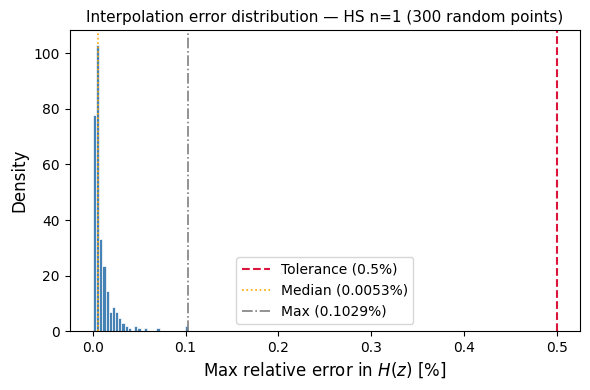

In [ ]:
# ====================================================
# Interpolation error distribution plot
# ====================================================

def plot_interpolation_errors(errors, tol_percent=0.5, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(errors, bins=30, color="steelblue", edgecolor="white",
            linewidth=0.5, density=True)
    ax.axvline(tol_percent, color="crimson", lw=1.5, ls="--",
               label=f"Tolerance ({tol_percent}%)")
    ax.axvline(np.median(errors), color="orange", lw=1.2, ls=":",
               label=f"Median ({np.median(errors):.4f}%)")
    ax.axvline(errors.max(), color="gray", lw=1.2, ls="-.",
               label=f"Max ({errors.max():.4f}%)")
    ax.set_xlabel("Max relative error in $H(z)$ [%]", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"Interpolation error distribution — HS n={n} (300 random points)",
                 fontsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_interpolation_errors(errors, save_path=f"interp_error_HS_n{n}_cc.png")

In [9]:
# ====================================================
# H(z) via interpolator
# ====================================================

def H_HS_interp(z_eval, H0, Om0, mu_HS):
    """Query interpolator with physical (linear) mu_HS."""
    
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), mu_HS),
        z_eval
    ])
    return H_interp_4D(pts)


# ==========================
# Quick test
# ==========================

print("H_HS_interp(z_cc) =", 
       H_HS_interp(z_cc, 70, 0.3, 0.0))

H_HS_interp(z_cc) = [ 72.32543061  73.03267143  74.13010426  76.05550239  76.41488751
  77.22656379  77.26740725  80.25665452  80.70199454  84.04092111
  85.41038246  86.39236459  86.41229232  87.64110763  88.93069057
  89.99660167  90.43783584  90.5282091   96.80939735 101.97878536
 106.33763652 106.33763652 108.32263921 109.55500951 114.53875978
 114.87740639 116.24019051 125.91092954 142.81429837 145.99112409
 151.07271373 156.5890366  165.02107884 184.38191594 204.3048027 ]


In [10]:
# ====================================================
# Observable error analysis
# ====================================================

def analyze_H_error_cc(H0, Om0, mu_HS):
    H_true   = H_HS_z(z_cc, H0, Om0, mu_HS)
    H_interp = H_HS_interp(z_cc, H0, Om0, mu_HS)
    if H_true is None or H_interp is None:
        print("Model evaluation failed.")
        return None
    abs_error          = np.abs(H_interp - H_true)
    rel_error          = abs_error / np.abs(H_true)
    pct_error          = 100.0 * rel_error
    chi_ratio          = abs_error / H_err
    chi2_per_point_max = np.max(chi_ratio**2)
    chi2_total_upper   = np.sum(chi_ratio**2)
    results = {
        "Metric": [
            "Max absolute error [km/s/Mpc]",
            "Median absolute error [km/s/Mpc]",
            "Max relative error",
            "Median relative error",
            "Max percent error [%]",
            "Median percent error [%]"
        ],
        "Value": [
            np.max(abs_error),
            np.median(abs_error),
            np.max(rel_error),
            np.median(rel_error),
            np.max(pct_error),
            np.median(pct_error)
        ]
    }
    df_results = pd.DataFrame(results)
    print(f"\n=== Observable Error Summary (HS n={n} | H using z_cc) ===\n")
    print(df_results.to_string(index=False))
    print("\n=== chi^2 Impact Assessment ===\n")
    print(f"Max |ΔH|/σ                     : {np.max(chi_ratio):.6e}")
    print(f"Max contribution to chi^2 (1pt): {chi2_per_point_max:.6e}")
    print(f"Total chi^2 shift (upper bound): {chi2_total_upper:.6e}")
    return df_results

_ = analyze_H_error_cc(H0=70.0, Om0=0.3, mu_HS=25.0)


=== Observable Error Summary (HS n=1 | H using z_cc) ===

                          Metric    Value
   Max absolute error [km/s/Mpc] 0.018333
Median absolute error [km/s/Mpc] 0.000678
              Max relative error 0.000090
           Median relative error 0.000009
           Max percent error [%] 0.008963
        Median percent error [%] 0.000891

=== chi^2 Impact Assessment ===

Max |ΔH|/σ                     : 6.646924e-04
Max contribution to chi^2 (1pt): 4.418159e-07
Total chi^2 shift (upper bound): 2.429044e-06


In [11]:
# ====================================================
# CC likelihood
# ====================================================

def lnprior_cc(theta_cc):
    H0, Om0, mu_HS = theta_cc
    if not (H0_min    <= H0    <= H0_max):     return -np.inf
    if not (Om0_min   <= Om0   <= Om0_max):    return -np.inf
    if not (mu_HS_min <= mu_HS <= mu_HS_max):  return -np.inf
    return 0.0

def lnlike_cc(theta_cc, z_cc, H_obs, H_err):
    H0, Om0, mu_HS = theta_cc
    H_model = H_HS_interp(z_cc, H0, Om0, mu_HS)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    return -0.5 * np.sum(((H_obs - H_model) / H_err)**2)

def lnprob_cc(theta_cc, z_cc, H_obs, H_err):
    lp = lnprior_cc(theta_cc)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc(theta_cc, z_cc, H_obs, H_err)


# ====================================================
# Quick test
# ====================================================

theta_cc_test = [70.0, 0.3, 50.0]
print("CC log-posterior =",
       lnprob_cc(theta_cc_test, z_cc, H_obs, H_err))

CC log-posterior = -7.603164018200624


In [12]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 3
nwalkers = 30
nsteps   = 30000

# Initial position
theta0 = np.array([70.0, 0.3,  25])  
scales = np.array([ 2.0, 0.02, 10])    

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))
for i in range(nwalkers):
    while not np.isfinite(lnprior_cc(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (HS n={n} | CC | Uniform prior on mu_HS) ===")
t_mcmc = time.time()
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc,
    args=(z_cc, H_obs, H_err)
)
sampler.run_mcmc(p0, nsteps, progress=True)
print(f"MCMC completed in {(time.time() - t_mcmc)/60:.2f} min")


=== Running MCMC (HS n=1 | CC | Uniform prior on mu_HS) ===


100%|██████████| 30000/30000 [01:35<00:00, 313.28it/s]

MCMC completed in 1.60 min


In [13]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")
chain        = sampler.get_chain()
nsteps_total = chain.shape[0]
acc_frac     = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn  = int(3 * tau_max)
nthin  = max(1, int(tau_max / 2))
n_post = nsteps_total - nburn
N_eff  = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.550
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 104.54
Chain length / τ_max           = 287.0
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 313 steps (1.0%)
Thin (τ_max/2)                 = 52
Minimum N_eff                  = 8519
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [14]:
# ====================================================
# Chain extraction
# ====================================================

# flat_samples = sampler.get_chain(discard=nburn, thin=nthin, flat=True)    # Apply thin
flat_samples = sampler.get_chain(discard=nburn, flat=True)                  # No thin

# Optional: save also with mu_HS_tilde = mu_HS / 100 and ln_mu_HS = ln(mu_HS)
flat_tilde        = flat_samples.copy()
flat_ln           = flat_samples.copy()

# mu_HS conversions
flat_tilde[:, 2]  = flat_samples[:, 2] / 100.0       # mu_HS → mu_HS_tilde
flat_ln[:, 2]     = np.log(flat_samples[:, 2])       # mu_HS → ln(mu_HS)

# Save both representations
fname       = f"flat_samples_HS_n{n}_cc.npy"
fname_tilde = f"flat_samples_HS_n{n}_cc_tilde.npy"
fname_ln    = f"flat_samples_HS_n{n}_cc_ln.npy"
np.save(fname,       flat_samples)
np.save(fname_tilde, flat_tilde)
np.save(fname_ln,    flat_ln)

print(f"\nFinal posterior samples : {len(flat_samples)}")
print(f"Burn-in used            : {nburn} steps")
print(f"Saved to                : {fname}")
print(f"Saved (tilde)           : {fname_tilde}  [mu_HS_tilde = mu_HS / 100]")
print(f"Saved (ln)              : {fname_ln}     [ln_mu_HS    = ln(mu_HS)]")


Final posterior samples : 890610
Burn-in used            : 313 steps
Saved to                : flat_samples_HS_n1_cc.npy
Saved (tilde)           : flat_samples_HS_n1_cc_tilde.npy  [mu_HS_tilde = mu_HS / 100]
Saved (ln)              : flat_samples_HS_n1_cc_ln.npy     [ln_mu_HS    = ln(mu_HS)]


Removed no burn in


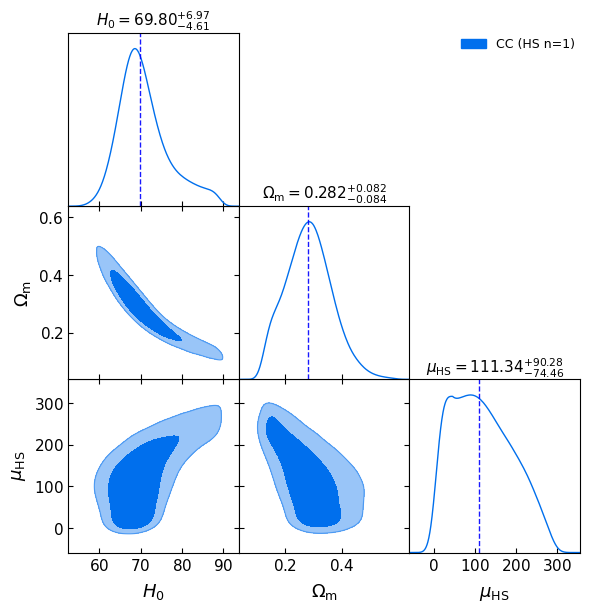

In [15]:
# ====================================================
# Corner plot (GetDist) — mu_HS directly
# ====================================================

param_names  = ["H0", "Om0", "mu_HS"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\mu_\mathrm{HS}"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "mu_HS": ".2f"}

samples_gd = MCSamples(
    samples=flat_samples,          
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"CC (HS n={n})"],
                title_limit=0)

# Add titles with median ± 68% CL
for i, name in enumerate(param_names):
    samp   = flat_samples[:, i]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = f"Corner_HS_n{n}_cc.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

Removed no burn in


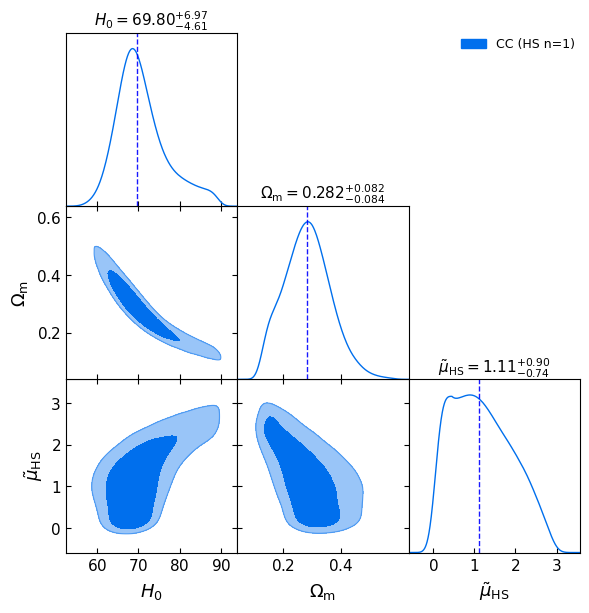

In [16]:
# ====================================================
# Corner plot (GetDist) — mu_HS_tilde = mu_HS / 100
# ====================================================

param_names  = ["H0", "Om0", "mu_HS_tilde"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\tilde{\mu}_\mathrm{HS}"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "mu_HS_tilde": ".2f"}

samples_gd = MCSamples(
    samples=flat_tilde,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"CC (HS n={n})"],
                title_limit=0)

for i, name in enumerate(param_names):
    samp    = flat_tilde[:, i]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)
plt.subplots_adjust(top=0.95)
    
figname = f"Corner_HS_n{n}_cc_tilde.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

Removed no burn in


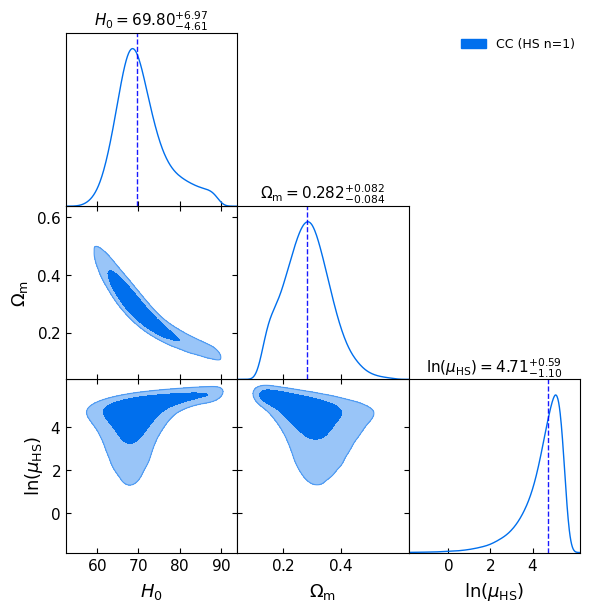

In [17]:
# ====================================================
# Corner plot (GetDist) — ln(mu_HS)
# ====================================================

param_names  = ["H0", "Om0", "ln_mu_HS"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\ln(\mu_\mathrm{HS})"]
fmt_map      = {"H0": ".2f", "Om0": ".3f", "ln_mu_HS": ".2f"}

samples_gd = MCSamples(
    samples=flat_ln,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=[f"CC (HS n={n})"],
                title_limit=0)

for i, name in enumerate(param_names):
    samp    = flat_ln[:, i]        
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax      = g.subplots[i, i]
    line    = ax.get_lines()[0]
    line.set_linewidth(1.0)
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)
    
plt.subplots_adjust(top=0.95)
figname = f"Corner_HS_n{n}_cc_ln.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# ====================================================
# Marginalized statistics
# ====================================================

print("\n" + "="*60)
print(f"{'Final Inference Results (HS n='+str(n)+' | CC data)':^60}")
print("="*60)

for name, idx, fmt in [("H0", 0, ".2f"), ("Om0", 1, ".3f")]:
    samp    = flat_samples[:, idx]
    median  = np.percentile(samp, 50)
    lower68 = np.percentile(samp, 16)
    upper68 = np.percentile(samp, 84)
    lower95 = np.percentile(samp, 2.5)
    upper95 = np.percentile(samp, 97.5)
    ep68 = upper68 - median;  em68 = median - lower68
    ep95 = upper95 - median;  em95 = median - lower95
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:.{fmt[1:]}}")

# mu_HS — physical
print(f"\n  mu_HS  [physical]:")
samp    = flat_samples[:, 2]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.2f} +{ep68:.2f} -{em68:.2f}  (68% CL)")
print(f"    {median:.2f} +{ep95:.2f} -{em95:.2f}  (95% CL)")

# mu_HS_tilde = mu_HS / 100
print(f"\n  mu_HS_tilde  [= mu_HS / 100]:")
samp    = flat_tilde[:, 2]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.4f} +{ep68:.4f} -{em68:.4f}  (68% CL)")
print(f"    {median:.4f} +{ep95:.4f} -{em95:.4f}  (95% CL)")

# ln(mu_HS)
print(f"\n  ln(mu_HS)  [= ln(mu_HS)]:")
samp    = flat_ln[:, 2]
median  = np.percentile(samp, 50)
lower68 = np.percentile(samp, 16)
upper68 = np.percentile(samp, 84)
lower95 = np.percentile(samp, 2.5)
upper95 = np.percentile(samp, 97.5)
ep68 = upper68 - median;  em68 = median - lower68
ep95 = upper95 - median;  em95 = median - lower95
print(f"    {median:.3f} +{ep68:.3f} -{em68:.3f}  (68% CL)")
print(f"    {median:.3f} +{ep95:.3f} -{em95:.3f}  (95% CL)")

print("\n" + "="*60)


         Final Inference Results (HS n=1 | CC data)         

  H0:
    69.80 +6.97 -4.61  (68% CL)
    69.80 +16.58 -8.80

  Om0:
    0.282 +0.082 -0.084  (68% CL)
    0.282 +0.174 -0.147

  mu_HS  [physical]:
    111.34 +90.28 -74.46  (68% CL)
    111.34 +155.04 -105.55  (95% CL)

  mu_HS_tilde  [= mu_HS / 100]:
    1.1134 +0.9028 -0.7446  (68% CL)
    1.1134 +1.5504 -1.0555  (95% CL)

  ln(mu_HS)  [= ln(mu_HS)]:
    4.713 +0.594 -1.105  (68% CL)
    4.713 +0.872 -2.955  (95% CL)



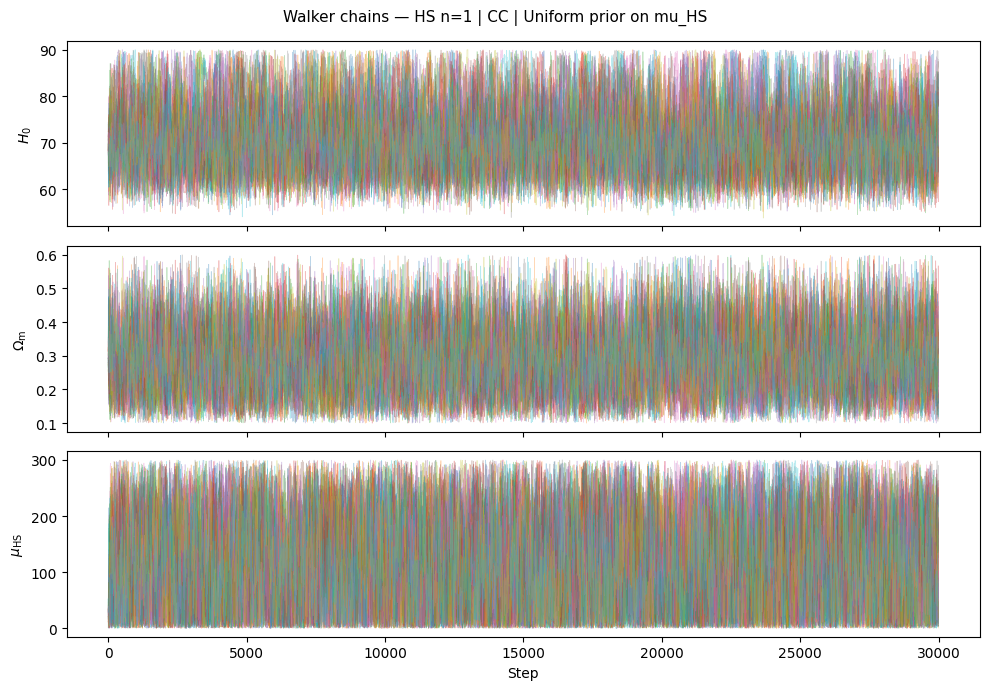

In [19]:
# ====================================================
# Walker chains
# ====================================================

chain_plot   = sampler.get_chain().copy()
chain_labels = [r"$H_0$", r"$\Omega_{\rm m}$", r"$\mu_\mathrm{HS}$"]

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
for i, label in enumerate(chain_labels):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.suptitle(f"Walker chains — HS n={n} | CC | Uniform prior on mu_HS",
             fontsize=11)

plt.tight_layout()
plt.show()